# ⚠️ Remaining Issues:
1. GED (in RT dist measure)
*        needs fixing: internal nodes mismatching effects the score in unexpected ways.
2. TBD

# Imports

In [1]:
from reticulate_tree import ReticulateTree
import compare_reticulations as cr
import importlib
import pandas as pd


# Example usages of ReticulateTree

Parsed ETE3 tree from enriched Newick: ((a:1,e:1):1,(b:1,e:1):1);



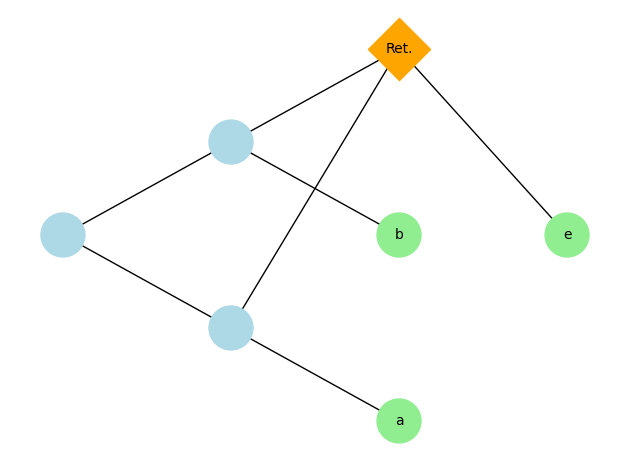

((a,(e)#H0),(b,#H0));


In [2]:
# Test the enewick input case:
test_enewick = '((a,(e)#H1:0),(#H1:0,b));'
# '((KBNS10,(SRR27702572,(SRR27702568,(((((KPIS19,(KSFS35)#H8),(KMTS31)#H6),(KRBS33)#H2),(KHUS06,(PZ382,(KCOS43,(KGUS05,(KPXS21)#H0))))),(KCUS03,(KVNS23)#H4))))),((((#H6,#H8),#H2),#H4),#H0));'
obj = ReticulateTree(test_enewick)
print(f'Parsed ETE3 tree from enriched Newick: {obj.tree_str}\n')
obj.visualize()
print(obj.to_enewick())


# Debug and usage of some compare funcs

In [3]:
input_A = {'a':2,'b':2,'c':1,'d':1,'e':1}
input_B = {'a':1,'b':2,'c':3,'d':1,'e':1}
res = cr.compare_ploidy_diff(input_A, input_B)
print(f'Ploidy Jaccard test result: {res}')
# We expect: {'dist': 0.75, 'FP': 2, 'FN': 1, 'TP': 1}
# out of 4 extra copies (1+1+2+0+0), 2 is correct (from b), 2 are false positive (both from c), 1 is false negative (from a)
# therefore the distance is 0.75 i.e., 3/4 differ = 1 - (1/4 match)

Ploidy Jaccard test result: {'dist': 0.75, 'FP': 2, 'FN': 1, 'TP': 1}


In [4]:
input_lA = {'1': ['z', 'y', 'x'], '2': ['w']}
input_sA = {'1': [{'a'}, {'b'}], '2': [{'c'}, {'d'}]}

input_lB = {'3': ['x', 'y', 'w', 'z'], '4': ['w']}
input_sB = {'3': [{'d', 'w', 'c'}, {'a'}], '4': [{'c'}, {'y', 'z'}]}

res = cr.match_and_compare(input_lA, input_lB)
print(f'Reticulation leaves test result: {res}')

res = cr.match_and_compare(input_lA, input_lB, input_sA, input_sB)
print(f'Reticulation sisters test result: {res}')

Reticulation leaves test result: {'dist': 0.125, 'FP': 0.125, 'FN': 0.0, 'TP': 0.875}
Reticulation sisters test result: {'dist': 0.5, 'FP': 0.5, 'FN': 0.5, 'TP': 0.5}


In [5]:
input1, input2 = {1:{'w', 'y'}, 2:{'c'}, 3:{'u', 'a', 'b'}, 4:{'z'}}, {1:{'y', 'z', 'x'}, 2:{'c'}, 3:{'a', 'b'}, 4:{'y', 'z'}, 5:{'u'}}

#input1, input2 = [{'c'}, {'u', 'a', 'b'}], [{'c'}, {'a', 'b'}, {'u'}]

cr.match_and_compare(input1, input2, debug=True)

# should u match to a,b,u too?

Hungarian leaves matching: [0 1 2 3], [0 1 2 3], 5
	for sets: [{'y', 'w'}, {'c'}, {'b', 'a', 'u'}, {'z'}], [{'z', 'y', 'x'}, {'c'}, {'b', 'a'}, {'z', 'y'}, {'u'}]
dists: [0.75, 0.0, 0.33333333333333337, 0.5]
FPs: [0.6666666666666666, 0.0, 0.0, 0.5]
FNs: [0.5, 0.0, 0.3333333333333333, 0.0]
Corrections: dist +1, FP +1, FN +0
Corrected norm. stats: dist=0.5167, FP=0.4333, FN=0.1667


{'dist': 0.5166666666666667,
 'FP': 0.4333333333333333,
 'FN': 0.16666666666666666,
 'TP': 0.4833333333333333}

In [6]:
input_lA = {'1': ['z', 'y', 'x'], '2': ['w'], '3': ['u', 'v']}
input_sA = {'1': [{'a'}, {'b'}], '2': [{'c'}, {'d', 'y'}], '3': [{'u'}, {'v'}]}

input_lB = {'3': ['x', 'y', 'w', 'z'], '4': ['w']}
input_sB = {'3': [{'d', 'w', 'c'}, {'a'}, {'u'}], '4': [{'c'}, {'y', 'z'}]}

res = cr.match_and_compare(input_lA, input_lB, input_sA, input_sB, debug=True)
print(f'Reticulation sisters test result: {res}')

Hungarian sisters matching: [0 1], [0 1], 3
	for sets: [{'z', 'y', 'x'}, {'w'}, {'v', 'u'}], [{'z', 'y', 'w', 'x'}, {'w'}]
Computing reticulation pair: 0, 0
Hungarian leaves matching: [0 1], [1 0], 3
	for sets: [{'a'}, {'b'}], [{'d', 'c', 'w'}, {'a'}, {'u'}]
dists: [0.0, 1.0]
FPs: [0.0, 1.0]
FNs: [0.0, 1.0]
Corrections: dist +1, FP +1, FN +0
Corrected norm. stats: dist=0.6667, FP=0.6667, FN=0.3333
Computing reticulation pair: 1, 1
Hungarian leaves matching: [0 1], [0 1], 2
	for sets: [{'c'}, {'d', 'y'}], [{'c'}, {'z', 'y'}]
dists: [0.0, 0.6666666666666667]
FPs: [0.0, 0.5]
FNs: [0.0, 0.5]
Corrections: dist +0, FP +0, FN +0
Corrected norm. stats: dist=0.3333, FP=0.2500, FN=0.2500
Corrections: dist +1, FP +0, FN +1
Corrected norm. stats: dist=0.6667, FP=0.3056, FN=0.5278
Reticulation sisters test result: {'dist': 0.6666666666666666, 'FP': 0.3055555555555555, 'FN': 0.5277777777777778, 'TP': 0.33333333333333337}


# Refresh lib

In [7]:
importlib.reload(cr)

<module 'compare_reticulations' from 'c:\\Users\\psfsitaymay\\Downloads\\Grampa_RT_etc\\Reticulate_Tree\\compare_reticulations.py'>

# Run all step by step

Name: no_reticules - newick: (((c,w),d)Q,((a,(x,(y,z))),b));
Nodes: 15, Edges: 14
Comparison vector: dict_values([0.0, 0, {'dist': 0.0, 'FP': 0, 'FN': 0, 'TP': 0}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 0.0}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 0.0}])
Is back-converted tree identical to original? True
Reticulation Count: 0
Reticulation Leaves: {}
Reticulation Sisters: {}
Leaf Counts: {'c': 1, 'w': 1, 'd': 1, 'a': 1, 'x': 1, 'y': 1, 'z': 1, 'b': 1}


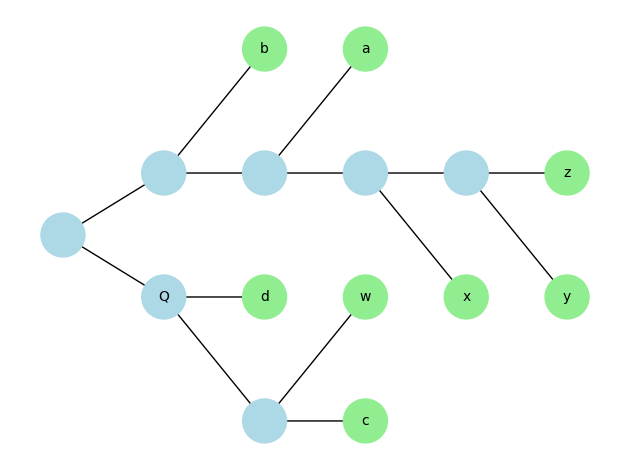



Name: no_intercladic - newick: (((c,w),(d,w)),((a,(x,(y,z))),(b,(x,(y,z)))));
Nodes: 19, Edges: 20
Comparison vector: dict_values([0.2564102564102564, 0, {'dist': 0.0, 'FP': 0, 'FN': 0, 'TP': 4}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}])
Is back-converted tree identical to original? True
Reticulation Count: 2
Reticulation Leaves: {'retic_2408535978880_2408535975232': ['x', 'z', 'y'], 'retic_2408535967408_2408535976480': ['w']}
Reticulation Sisters: {'retic_2408535978880_2408535975232': [{'a'}, {'b'}], 'retic_2408535967408_2408535976480': [{'c'}, {'d'}]}
Leaf Counts: {'c': 1, 'w': 2, 'd': 1, 'a': 1, 'x': 2, 'y': 2, 'z': 2, 'b': 1}


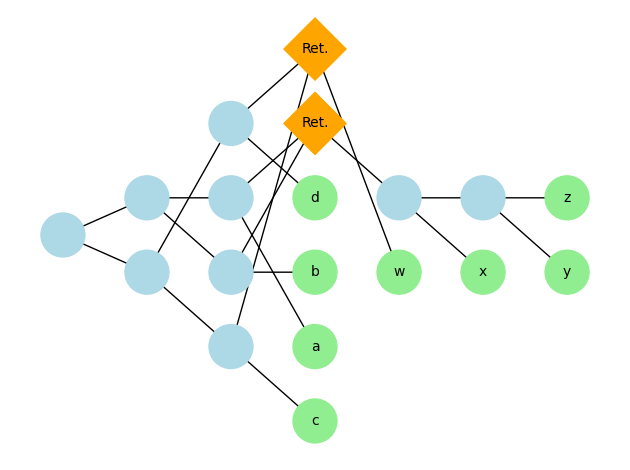



Name: no_nested - newick: ((((c,w),(d,w))Q,(x,(y,z))),((a,(x,(y,z))),b));
Nodes: 19, Edges: 20
Comparison vector: dict_values([0.2564102564102564, 0, {'dist': 0.0, 'FP': 0, 'FN': 0, 'TP': 4}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}])
Is back-converted tree identical to original? True
Reticulation Count: 2
Reticulation Leaves: {'retic_2408536129216_2408536127776': ['y', 'z', 'x'], 'retic_2408536127680_2408536127536': ['w']}
Reticulation Sisters: {'retic_2408536129216_2408536127776': [{'d', 'c', 'w'}, {'a'}], 'retic_2408536127680_2408536127536': [{'c'}, {'d'}]}
Leaf Counts: {'c': 1, 'w': 2, 'd': 1, 'x': 2, 'y': 2, 'z': 2, 'a': 1, 'b': 1}


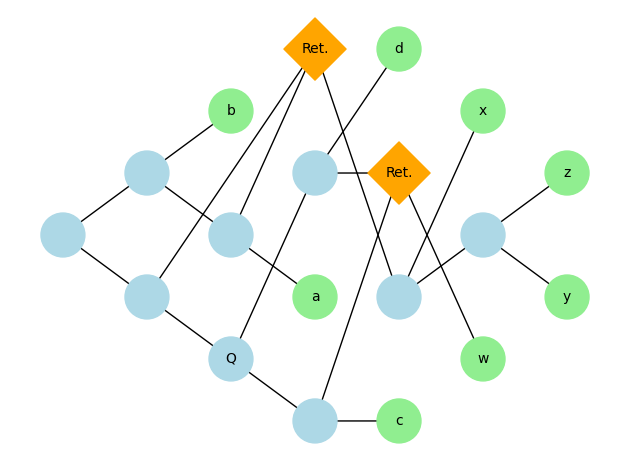



Name: semi_nested - newick: ((((c,w),d),(x,((y,z),w))),((a,(x,((y,z),w))),b));
Nodes: 19, Edges: 20
Comparison vector: dict_values([0.2564102564102564, 0, {'dist': 0.0, 'FP': 0, 'FN': 0, 'TP': 5}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}])
Is back-converted tree identical to original? True
Reticulation Count: 2
Reticulation Leaves: {'retic_2408528510560_2408528501008': ['y', 'z', 'x', 'w'], 'retic_2408528510416_2408528505232': ['w']}
Reticulation Sisters: {'retic_2408528510560_2408528501008': [{'d', 'c', 'w'}, {'a'}], 'retic_2408528510416_2408528505232': [{'c'}, {'z', 'y'}]}
Leaf Counts: {'c': 1, 'w': 3, 'd': 1, 'x': 2, 'y': 2, 'z': 2, 'a': 1, 'b': 1}


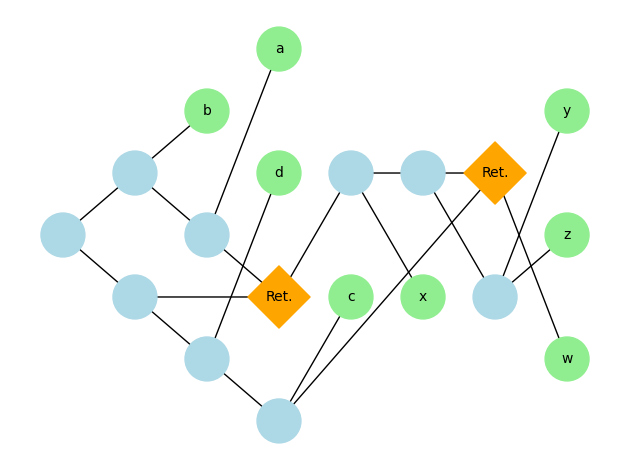



Name: once_nested - newick: (((c,d),((x,w),((y,z),w))),((a,((x,w),((y,z),w))),b));
Nodes: 19, Edges: 20
Comparison vector: dict_values([0.358974358974359, 0, {'dist': 0.0, 'FP': 0, 'FN': 0, 'TP': 6}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}])
Is back-converted tree identical to original? True
Reticulation Count: 2
Reticulation Leaves: {'retic_2408535974272_2408535800912': ['z', 'x', 'w', 'y'], 'retic_2408535794528_2408535794672': ['w']}
Reticulation Sisters: {'retic_2408535974272_2408535800912': [{'d', 'c'}, {'a'}], 'retic_2408535794528_2408535794672': [{'x'}, {'z', 'y'}]}
Leaf Counts: {'c': 1, 'd': 1, 'x': 2, 'w': 4, 'y': 2, 'z': 2, 'a': 1, 'b': 1}


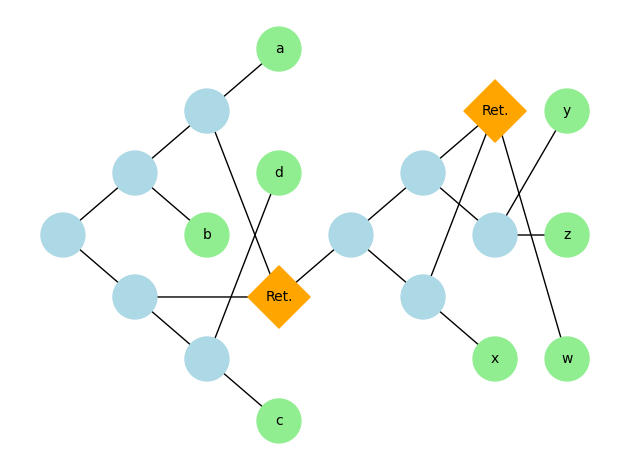



Name: semi_broken1 - newick: ((((c,w),d),(x,(y,z))),((a,(x,((y,z),w))),b));
Nodes: 21, Edges: 23
Comparison vector: dict_values([0.5, 0, {'dist': 0.0, 'FP': 0, 'FN': 0, 'TP': 4}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}])
Is back-converted tree identical to original? True
Reticulation Count: 3
Reticulation Leaves: {'retic_2408535792752_2408535793568': ['z', 'y'], 'retic_2408535789728_2408535789296': ['w'], 'retic_2408535792752_2408535801536': ['x']}
Reticulation Sisters: {'retic_2408535792752_2408535793568': [{'x'}, {'w'}], 'retic_2408535789728_2408535789296': [{'c'}, {'z', 'y'}], 'retic_2408535792752_2408535801536': [{'z', 'y'}, {'z', 'y', 'w'}]}
Leaf Counts: {'c': 1, 'w': 2, 'd': 1, 'x': 2, 'y': 2, 'z': 2, 'a': 1, 'b': 1}


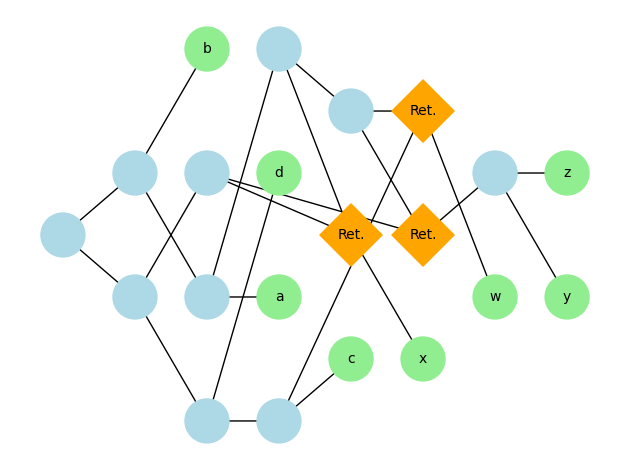



Name: semi_broken2 - newick: ((((c,w),d),(x,((y,z),w))),((a,(x,(y,z))),b));
Nodes: 21, Edges: 23
Comparison vector: dict_values([0.36363636363636365, 0, {'dist': 0.0, 'FP': 0, 'FN': 0, 'TP': 4}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}])
Is back-converted tree identical to original? True
Reticulation Count: 3
Reticulation Leaves: {'retic_2408535969040_2408528935968': ['z', 'y'], 'retic_2408538569376_2408528931264': ['w'], 'retic_2408535973600_2408535972208': ['x']}
Reticulation Sisters: {'retic_2408535969040_2408528935968': [{'w'}, {'x'}], 'retic_2408538569376_2408528931264': [{'c'}, {'z', 'y'}], 'retic_2408535973600_2408535972208': [{'z', 'y', 'w'}, {'z', 'y'}]}
Leaf Counts: {'c': 1, 'w': 2, 'd': 1, 'x': 2, 'y': 2, 'z': 2, 'a': 1, 'b': 1}


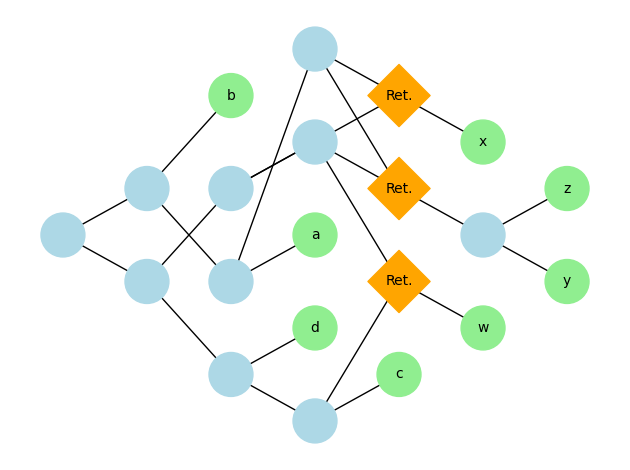



Name: semi_shifted1 - newick: ((((c,w),d),(x,(y,(z,w)))),((a,(x,((y,z),w))),b));
Nodes: 24, Edges: 28
This indicates that a Strict MUL-to-Net mode was used on a malformed inference.
This indicates that a Strict MUL-to-Net mode was used on a malformed inference.
Comparison vector: dict_values([0.46153846153846156, 0, {'dist': 0.0, 'FP': 0, 'FN': 0, 'TP': 5}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}])
Is back-converted tree identical to original? True
This indicates that a Strict MUL-to-Net mode was used on a malformed inference.
Reticulation Count: 4
Reticulation Leaves: {'retic_2408536328144_2408539188512': ['w'], 'retic_2408539186976_2408539191872': ['x'], 'retic_2408536329488_2408539188608': ['y'], 'retic_2408539189952_2408539181888': ['z']}
Reticulation Sisters: {'retic_2408536328144_2408539188512': [{'c'}, {'z'}, {'z', 'y'}], 'retic_2408539186976_2408539191872': [{'z', 'y', 'w'}, {'z', 'y', 'w'}], 'retic_2408536329488_24085391

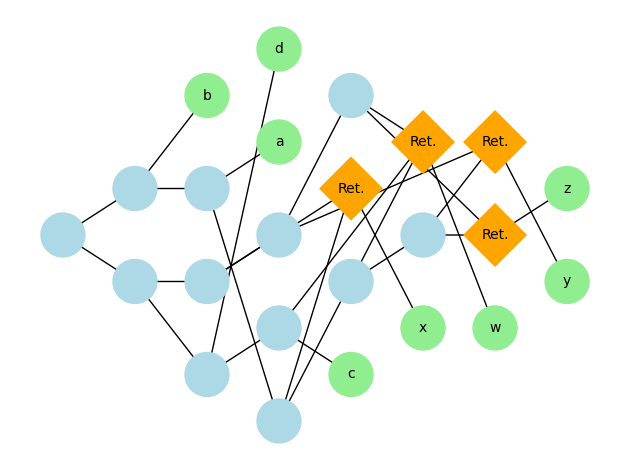



Name: semi_shifted2 - newick: ((((c,w),d),(x,((y,z),w))),((a,((x,(y,z)),w)),b));
Nodes: 22, Edges: 25
This indicates that a Strict MUL-to-Net mode was used on a malformed inference.
This indicates that a Strict MUL-to-Net mode was used on a malformed inference.
Comparison vector: dict_values([0.3404255319148936, 0, {'dist': 0.0, 'FP': 0, 'FN': 0, 'TP': 5}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}, {'dist': 0.0, 'FP': 0.0, 'FN': 0.0, 'TP': 1.0}])
Is back-converted tree identical to original? True
This indicates that a Strict MUL-to-Net mode was used on a malformed inference.
Reticulation Count: 3
Reticulation Leaves: {'retic_2408539607152_2408538405824': ['z', 'y'], 'retic_2408539607200_2408539604944': ['w'], 'retic_2408539607296_2408539613824': ['x']}
Reticulation Sisters: {'retic_2408539607152_2408538405824': [{'w'}, {'x'}], 'retic_2408539607200_2408539604944': [{'c'}, {'z', 'y'}, {'z', 'y', 'x'}], 'retic_2408539607296_2408539613824': [{'z', 'y', 'w'}, {'z', 'y'}]}
Leaf Counts

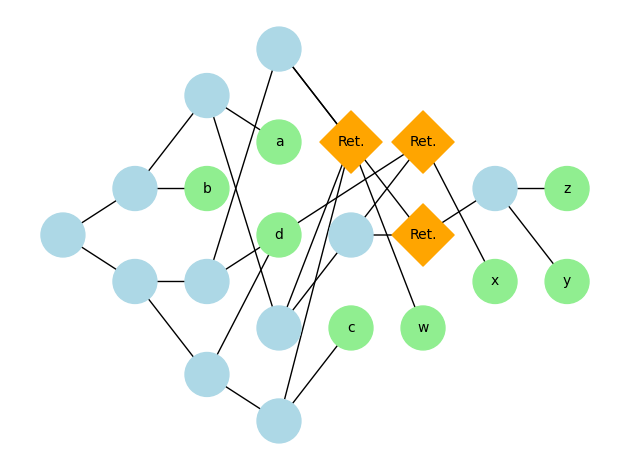

In [8]:
# Test a family of MUL-trees derived from the same single-labeled tree (all kinds of reticulation placements):
phylo_trees = {
    'no_reticules': '(((c,w),d)Q,((a,(x,(y,z))),b));',
    'no_intercladic': '(((c,w),(d,w)),((a,(x,(y,z))),(b,(x,(y,z)))));',
    'no_nested': '((((c,w),(d,w))Q,(x,(y,z))),((a,(x,(y,z))),b));',
    'semi_nested': '((((c,w),d),(x,((y,z),w))),((a,(x,((y,z),w))),b));',
    'once_nested': '(((c,d),((x,w),((y,z),w))),((a,((x,w),((y,z),w))),b));',
    'semi_broken1': '((((c,w),d),(x,(y,z))),((a,(x,((y,z),w))),b));',
    'semi_broken2': '((((c,w),d),(x,((y,z),w))),((a,(x,(y,z))),b));',
    'semi_shifted1': '((((c,w),d),(x,(y,(z,w)))),((a,(x,((y,z),w))),b));',
    'semi_shifted2': '((((c,w),d),(x,((y,z),w))),((a,((x,(y,z)),w)),b));',
}

phylo_trees_data = []
for name, newick_str in phylo_trees.items():

    # MUL-tree string parsing tests
    phylo_trees[name] = ReticulateTree(newick_str)
    curr_obj = phylo_trees[name]
    print(f'Name: {name} - newick: {curr_obj.tree_str}')

    # Back-conversion test:
    dag = curr_obj.dag
    print(f'Nodes: {dag.number_of_nodes()}, Edges: {dag.number_of_edges()}')
    back_tree = ReticulateTree.dag_to_multree(dag)
    #print(f'Converted back to tree: {back_tree.write(format=8)}')

    # Check if the back-converted tree matches the original
    print(f'Is back-converted tree identical to original? {cr.are_identical(curr_obj, ReticulateTree(back_tree))}')

    # Measure the object and check printout
    object_measurements = curr_obj.measure(printout=True)

    phylo_trees_data.append({
        'name': name,
        'object': curr_obj,
        **object_measurements
    })

    # Visualize the object
    curr_obj.visualize()#main_path / f'{name}_dag.png')

    # Interactive visualization (if needed)
    #curr_obj.interact(main_path / f'{name}_interactive.html', launch=True)

    print('\n')

In [9]:
# Create a DataFrame for the phylogenetic trees data
phylo_df = pd.DataFrame(phylo_trees_data).set_index('name')

In [10]:
# Generate pairwise comparison matrices
comparison_matrices = cr.pairwise_comparison(phylo_df)

for metric, matrix in comparison_matrices.items():
    print(f'\n{metric.upper()} matrix:')
    print(matrix.round(3))

Comparing 9 trees...

EDIT_DISTANCE matrix:
name            no_reticules  no_intercladic  no_nested  semi_nested  \
name                                                                   
no_reticules           0.000           0.949      0.615        0.795   
no_intercladic         0.949           0.000      0.590        0.769   
no_nested              0.615           0.590      0.000        0.590   
semi_nested            0.795           0.769      0.590        0.000   
once_nested            0.846           0.769      0.795        0.308   
semi_broken1           0.773           0.841      0.773        0.750   
semi_broken2           0.818           0.886      0.864        0.614   
semi_shifted1          0.885           0.865      0.923        0.788   
semi_shifted2          0.830           0.936      0.872        0.638   

name            once_nested  semi_broken1  semi_broken2  semi_shifted1  \
name                                                                     
no_reticules   

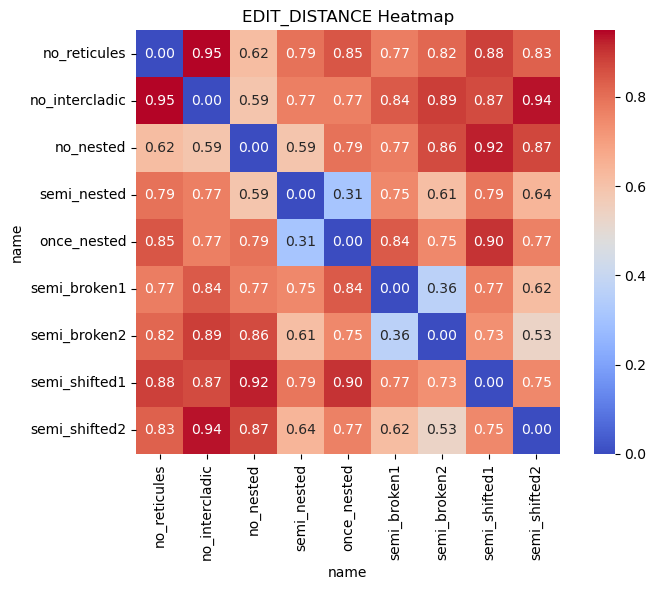

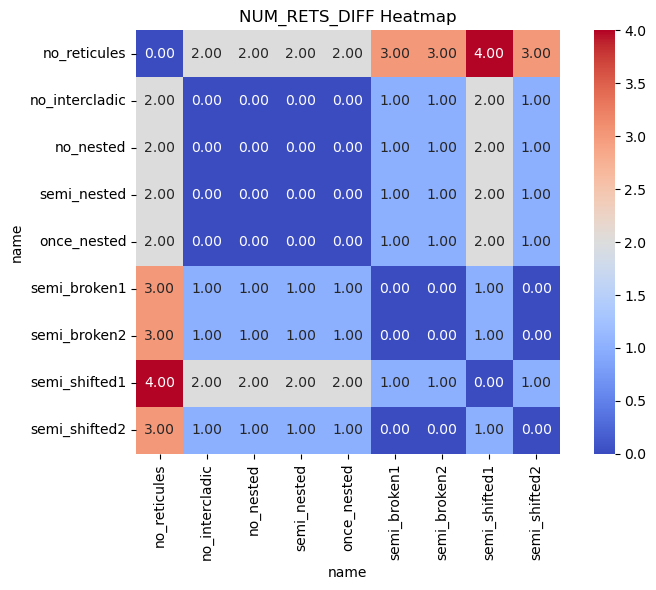

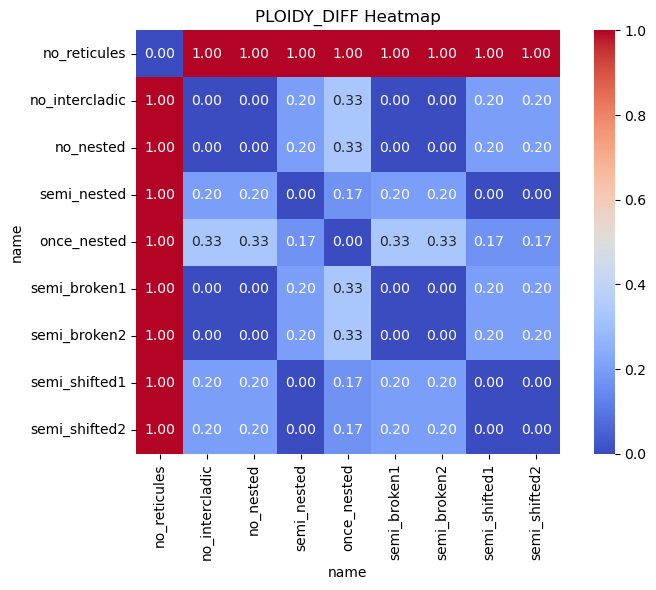

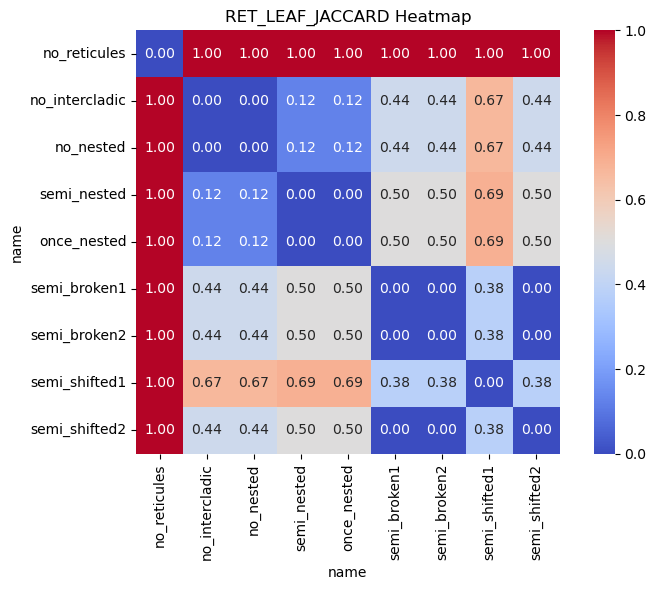

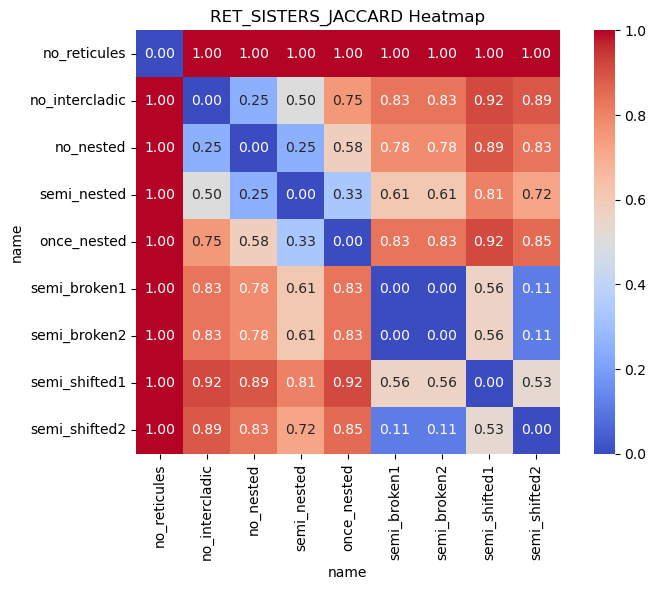

In [11]:
cr.plot_comparison_heatmaps(comparison_matrices, phylo_df)

# One stop shop

In [12]:
phylo_trees = {
    'no_reticules': '(((c,w),d)Q,((a,(x,(y,z))),b));',
    'no_intercladic': '(((c,w),(d,w)),((a,(x,(y,z))),(b,(x,(y,z)))));',
    'no_nested': '((((c,w),(d,w))Q,(x,(y,z))),((a,(x,(y,z))),b));',
    'semi_nested': '((((c,w),d),(x,((y,z),w))),((a,(x,((y,z),w))),b));',
    'once_nested': '(((c,d),((x,w),((y,z),w))),((a,((x,w),((y,z),w))),b));',
    'semi_broken1': '((((c,w),d),(x,(y,z))),((a,(x,((y,z),w))),b));',
    'semi_broken2': '((((c,w),d),(x,((y,z),w))),((a,(x,(y,z))),b));',
    'semi_shifted1': '((((c,w),d),(x,(y,(z,w)))),((a,(x,((y,z),w))),b));',
    'semi_shifted2': '((((c,w),d),(x,((y,z),w))),((a,((x,(y,z)),w)),b));',
}

results = cr.one_stop_compare(phylo_trees, printout=False)

This indicates that a Strict MUL-to-Net mode was used on a malformed inference.
This indicates that a Strict MUL-to-Net mode was used on a malformed inference.
Comparing 9 trees...


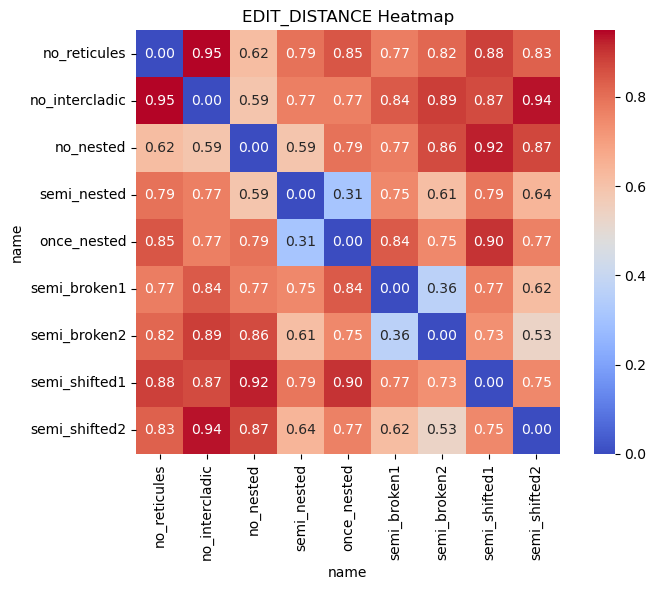

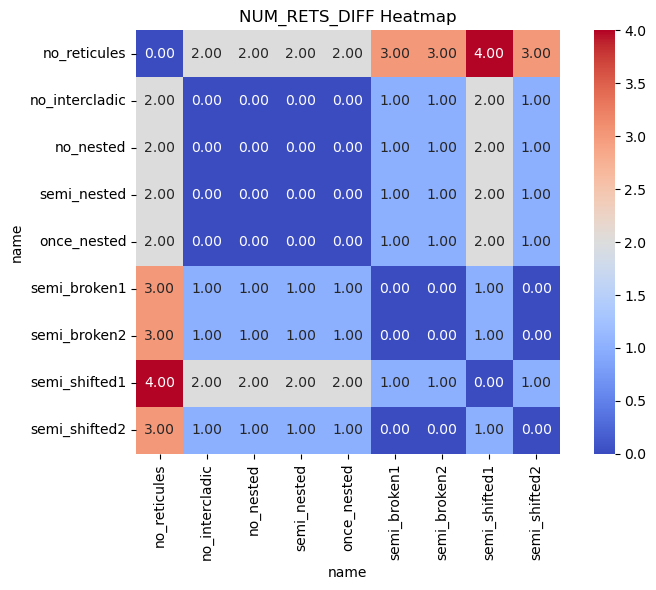

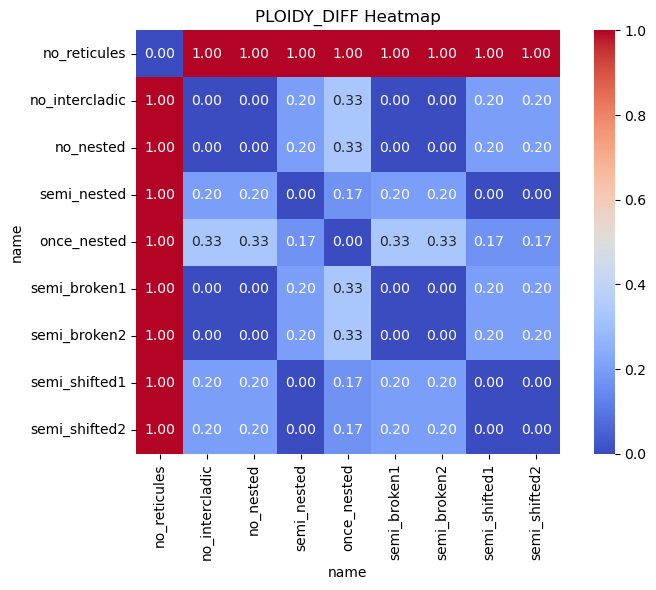

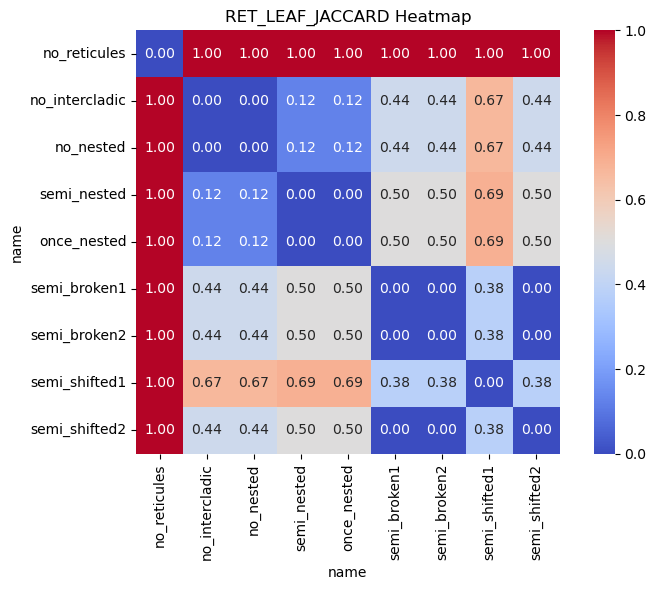

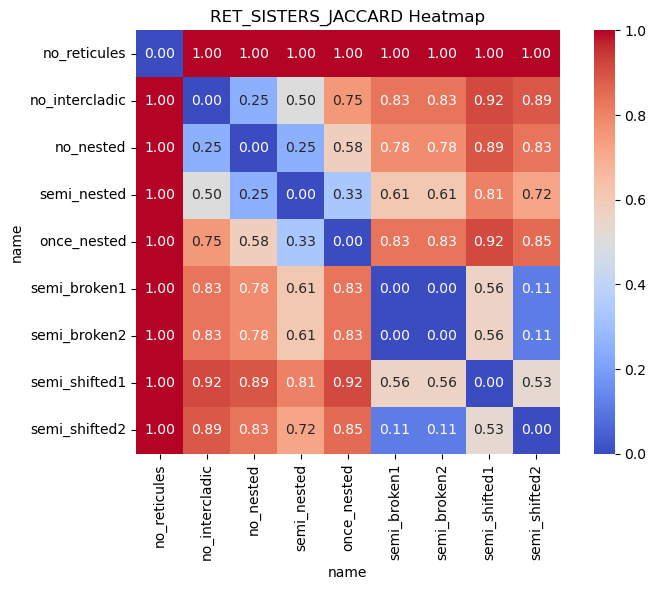

In [13]:
cr.plot_comparison_heatmaps(results['comparisons'], results['data'])